# Setup

### Imports

In [1]:
import numpy as np
import pandas as pd
import krippendorff as kd
import roman
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import colormaps
from matplotlib import rcParams

import warnings

warnings.filterwarnings("ignore")


In [2]:
rcParams['font.family'] = 'STIXGeneral'
rcParams['font.size'] = 12  # Optional: adjust to match Overleaf's text size

rcParams.update({
    "font.size": 12,       
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300
    }
)

fig_width = 7
fig_height = fig_width * 0.66  # Aspect ratio: adjust to taste or data

figsize_horizontal = (fig_width, fig_height)


### Data Loading

In [3]:
block_ids_df = pd.read_csv("EDA/data/block_ids.csv")
block_ids_df.rename(columns={"0": "ids"}, inplace=True)
block_ids_df["ids"] = block_ids_df["ids"].str.replace("RL-", "").str.lstrip("0")

block_ids_df

,ids
0,6-I
1,7-II
2,7-III
3,7-IV
4,12-I
...,...
1582,1098-I
1583,1098-II
1584,1099-I
1585,1100-I


In [4]:
data = pd.read_excel("EDA/data/cleaned_data_biopsy level_all_pathologists_FINAL-1-1173.xlsx", index_col=0)
data = data[data["Case"].isin(block_ids_df["ids"])]

In [5]:
data.rename(columns={"Case": "case", "Referral diagnosis biopsy level": "initial dx", "GS biopsy level": "consensus dx"}, inplace=True)


i = 0
for col in data.columns[data.columns.str.contains("Path")]:
    i += 1
    data.rename({col: f"path_{i}_dx"}, axis=1, inplace=True)

In [6]:
data.describe()

,initial dx,consensus dx,path_1_dx,path_2_dx,path_3_dx,path_4_dx,path_5_dx,path_6_dx,path_7_dx,path_8_dx,...,path_11_dx,path_12_dx,path_13_dx,path_14_dx,path_15_dx,path_16_dx,path_17_dx,path_18_dx,path_19_dx,path_20_dx
count,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,...,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000,1577.000000
mean,2.155358,2.154724,1.097020,2.145847,1.823716,1.024731,0.915663,0.480659,1.287254,0.395054,...,1.498415,1.468611,1.398224,0.654407,1.317692,1.059607,0.982879,0.644261,0.974001,0.551046
std,0.954862,1.149445,1.288409,1.146185,1.385886,1.334821,1.244221,0.972222,1.317318,0.988154,...,1.420983,1.410326,1.381053,1.206647,1.262460,1.363594,1.300756,1.190975,1.284902,1.033125
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,1.000000,0.000000,3.000000,0.000000,...,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,2.000000,1.000000,2.000000,1.000000
max,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1577 entries, 7 to 2084
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   case          1577 non-null   object
 1   initial dx    1577 non-null   int64 
 2   consensus dx  1577 non-null   int64 
 3   path_1_dx     1577 non-null   int64 
 4   path_2_dx     1577 non-null   int64 
 5   path_3_dx     1577 non-null   int64 
 6   path_4_dx     1577 non-null   int64 
 7   path_5_dx     1577 non-null   int64 
 8   path_6_dx     1577 non-null   int64 
 9   path_7_dx     1577 non-null   int64 
 10  path_8_dx     1577 non-null   int64 
 11  path_9_dx     1577 non-null   int64 
 12  path_10_dx    1577 non-null   int64 
 13  path_11_dx    1577 non-null   int64 
 14  path_12_dx    1577 non-null   int64 
 15  path_13_dx    1577 non-null   int64 
 16  path_14_dx    1577 non-null   int64 
 17  path_15_dx    1577 non-null   int64 
 18  path_16_dx    1577 non-null   int64 
 19  path_17_dx 

### Data Cleaning and Preprocessing

Some case identifiers contain an old naming convention that specifies returning visits of patients. It was decided to remove returning visits and keep only the first visit of each patient.

In [8]:
double_visits = data.loc[data["case"].str.contains("_")]
double_visits = double_visits.loc[double_visits["case"].str.contains("_1") == False]
data = data.drop(double_visits.index)
data.loc[data["case"].str.contains("_"), "case"] = data.loc[data["case"].str.contains("_"), "case"].str.replace("_1", "")

During other initial preprocessing steps, an error occured due to a case identifier including "1.5" in the place of the block identifier. Consequently, this row was dropped due to the unclear circumstances under which that identifier was chosen.

In [9]:
data = data[data["case"].str.contains("-1.5") == False]

As analyses will be carried out on both a patient and block level, the case identifier is split into block and patient columns that ease grouping or aggregations.

In [10]:
data["patient"] = data["case"].str.split("-").str[0].astype(int)
data["block"] = data["case"].str.split("-").str[1].str.strip().apply(roman.fromRoman)
data[["case", "block", "patient"]]

,case,block,patient
7,6-I,1,6
9,7-II,2,7
10,7-III,3,7
11,7-IV,4,7
35,14-I,1,14
...,...,...,...
2080,1098-I,1,1098
2081,1098-II,2,1098
2082,1099-I,1,1099
2083,1100-I,1,1100


In the provided dataset, no diagnosis is indicated by a 0. To support usage of native pandas-functions that can be used to describe the data, 0s will be converted to np.nan-values. Also, agreement measures between raters, that natively handle missing values (e.g., Krippendorff's alpha coefficient), require a missing-value format.

In [11]:
data.replace(0, np.nan, inplace=True)

To access features of interest more easily during the analysis, a list containing all columns of pathologist diagnoses is created.

In [12]:
pathologists = data.columns[data.columns.str.contains("path")]

In [13]:
non_null_counts = data[pathologists].notnull().sum(axis=1)
non_null_counts.max()

18

### Colormaps

To support understanding of the following visualizations, colormaps are defined in this section. Both a sequential and a divergent colormap are defined to account for different visualization cases.

#### sequential

As a sequential colormap, a custom colormap was created. Other than similar matplotlib-native colormaps, this colormap ranges from **pure** white for low values (0) to 'mediumblue' for high values (1), which is also used in the divergent colormap described below. This colormap will be used for value ranges without a distinct center point.

In [14]:
# from matplotlib.colors import LinearSegmentedColormap

# seq_cm = LinearSegmentedColormap.from_list('custom_blues', ['white', 'mediumblue'])

# fig, ax = plt.subplots(figsize=(6, 1))
# fig.subplots_adjust(bottom=0.5)
# norm = mcolors.Normalize(vmin=0, vmax=1)
# cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=seq_cm), cax=ax, orientation='horizontal')
# cb.set_label('Custom Colormap: White to Medium Blue')
# cb.set_ticks([0, 0.5, 1])
# plt.show()

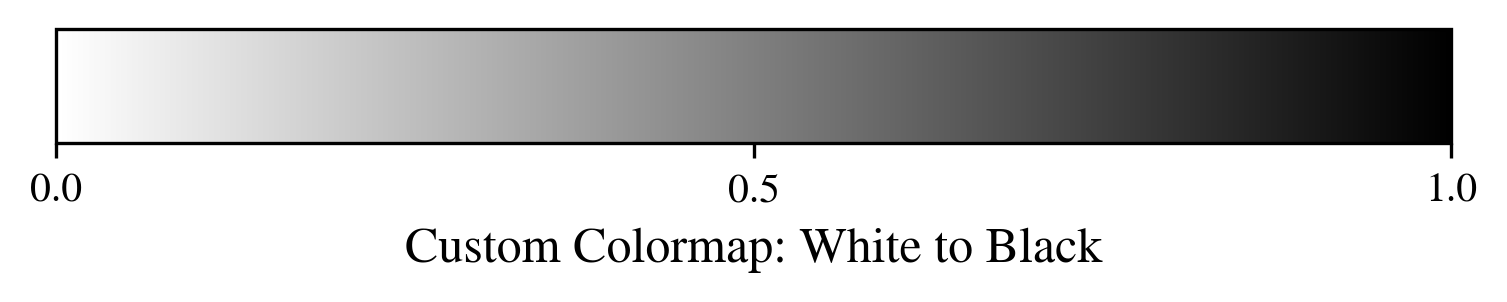

In [15]:
from matplotlib.colors import LinearSegmentedColormap

seq_cm = LinearSegmentedColormap.from_list('custom_blues', ['white', 'Black'])

fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)
norm = mcolors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=seq_cm), cax=ax, orientation='horizontal')
cb.set_label('Custom Colormap: White to Black')
cb.set_ticks([0, 0.5, 1])
plt.show()

#### divergent

The chosen divergent colormap 'bwr' is intended for usage in cases with a distinct center point. To offer a more intuitive interpretation, the colormap is reversed to indicate low values (-1 to 0) in increasingly saturated red and high values (0 to 1) in blue. 

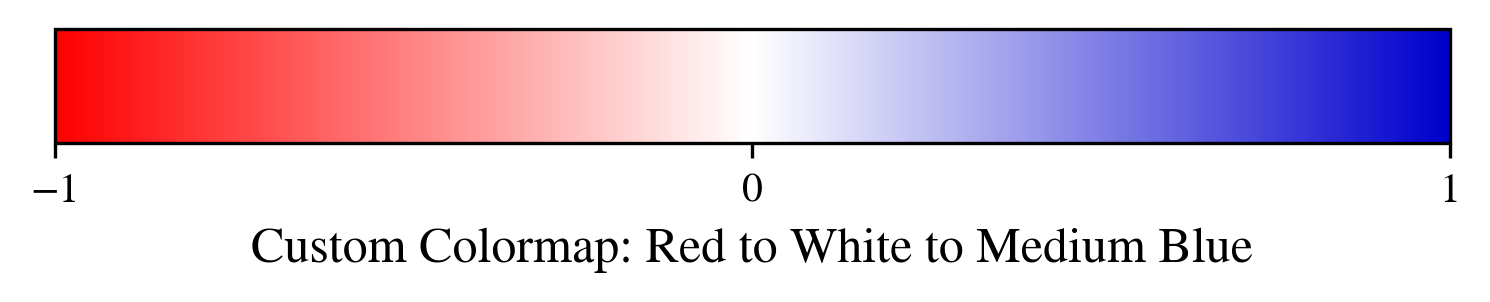

In [16]:
from matplotlib.colors import LinearSegmentedColormap

div_cm = LinearSegmentedColormap.from_list('custom_red_white_blue', ['red', 'white', 'mediumblue'])

fig, ax = plt.subplots(figsize=(6, 1))
fig.subplots_adjust(bottom=0.5)
norm = mcolors.Normalize(vmin=-1, vmax=1)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=div_cm), cax=ax, orientation='horizontal')
cb.set_label('Custom Colormap: Red to White to Medium Blue')
cb.set_ticks([-1, 0, 1])
plt.show()

In [17]:
def annotate_heatmap(data, number_of_common_rows):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            plt.text(j + 0.5, i + 0.5, f'{data[i, j]:.2f}\n({int(number_of_common_rows[i, j])})', 
                        color='black', ha='center', va='center', fontsize=5.5)
            
def annotate_withoutcommon(data):
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data.iloc[i, j]):
                plt.text(j + 0.5, i + 0.5, f'{data.iloc[i, j]:.2f}', ha='center', va='center', color='black')


# Analysis

In [ ]:
results = pd.read_csv("../../../experiments/reliability_scores.csv")
results

FileNotFoundError: [Errno 2] No such file or directory: '../../../experiments/intra/aa_krippendorff_alpha_per_path.csv'

### Clustering

In [19]:
pairwise_corr_nonagg = pd.DataFrame(columns=[np.arange(1, len(pathologists) + 1)], index=[np.arange(1, len(pathologists) + 1)])
number_of_common_rows_nonagg = pd.DataFrame(columns=[np.arange(1, len(pathologists) + 1)], index=[np.arange(1, len(pathologists) + 1)])
for i in range(1, len(pathologists) + 1):
    for j in range(1, len(pathologists) + 1):
        pairwise_df = data[[f"path_{i}_dx", f"path_{j}_dx"]]
        number_of_common_rows_nonagg.loc[i,j] = len(pairwise_df.dropna())
        if len(pairwise_df[pairwise_df.isna().any(axis=1)]) == len(pairwise_df):
            pairwise_corr_nonagg.loc[i,j] = np.nan
        else:
            pairwise_corr_nonagg.loc[i,j] = kd.alpha(pairwise_df.T.values, level_of_measurement="nominal", value_domain=[np.nan, 1.0, 2.0, 3.0, 4.0])
            

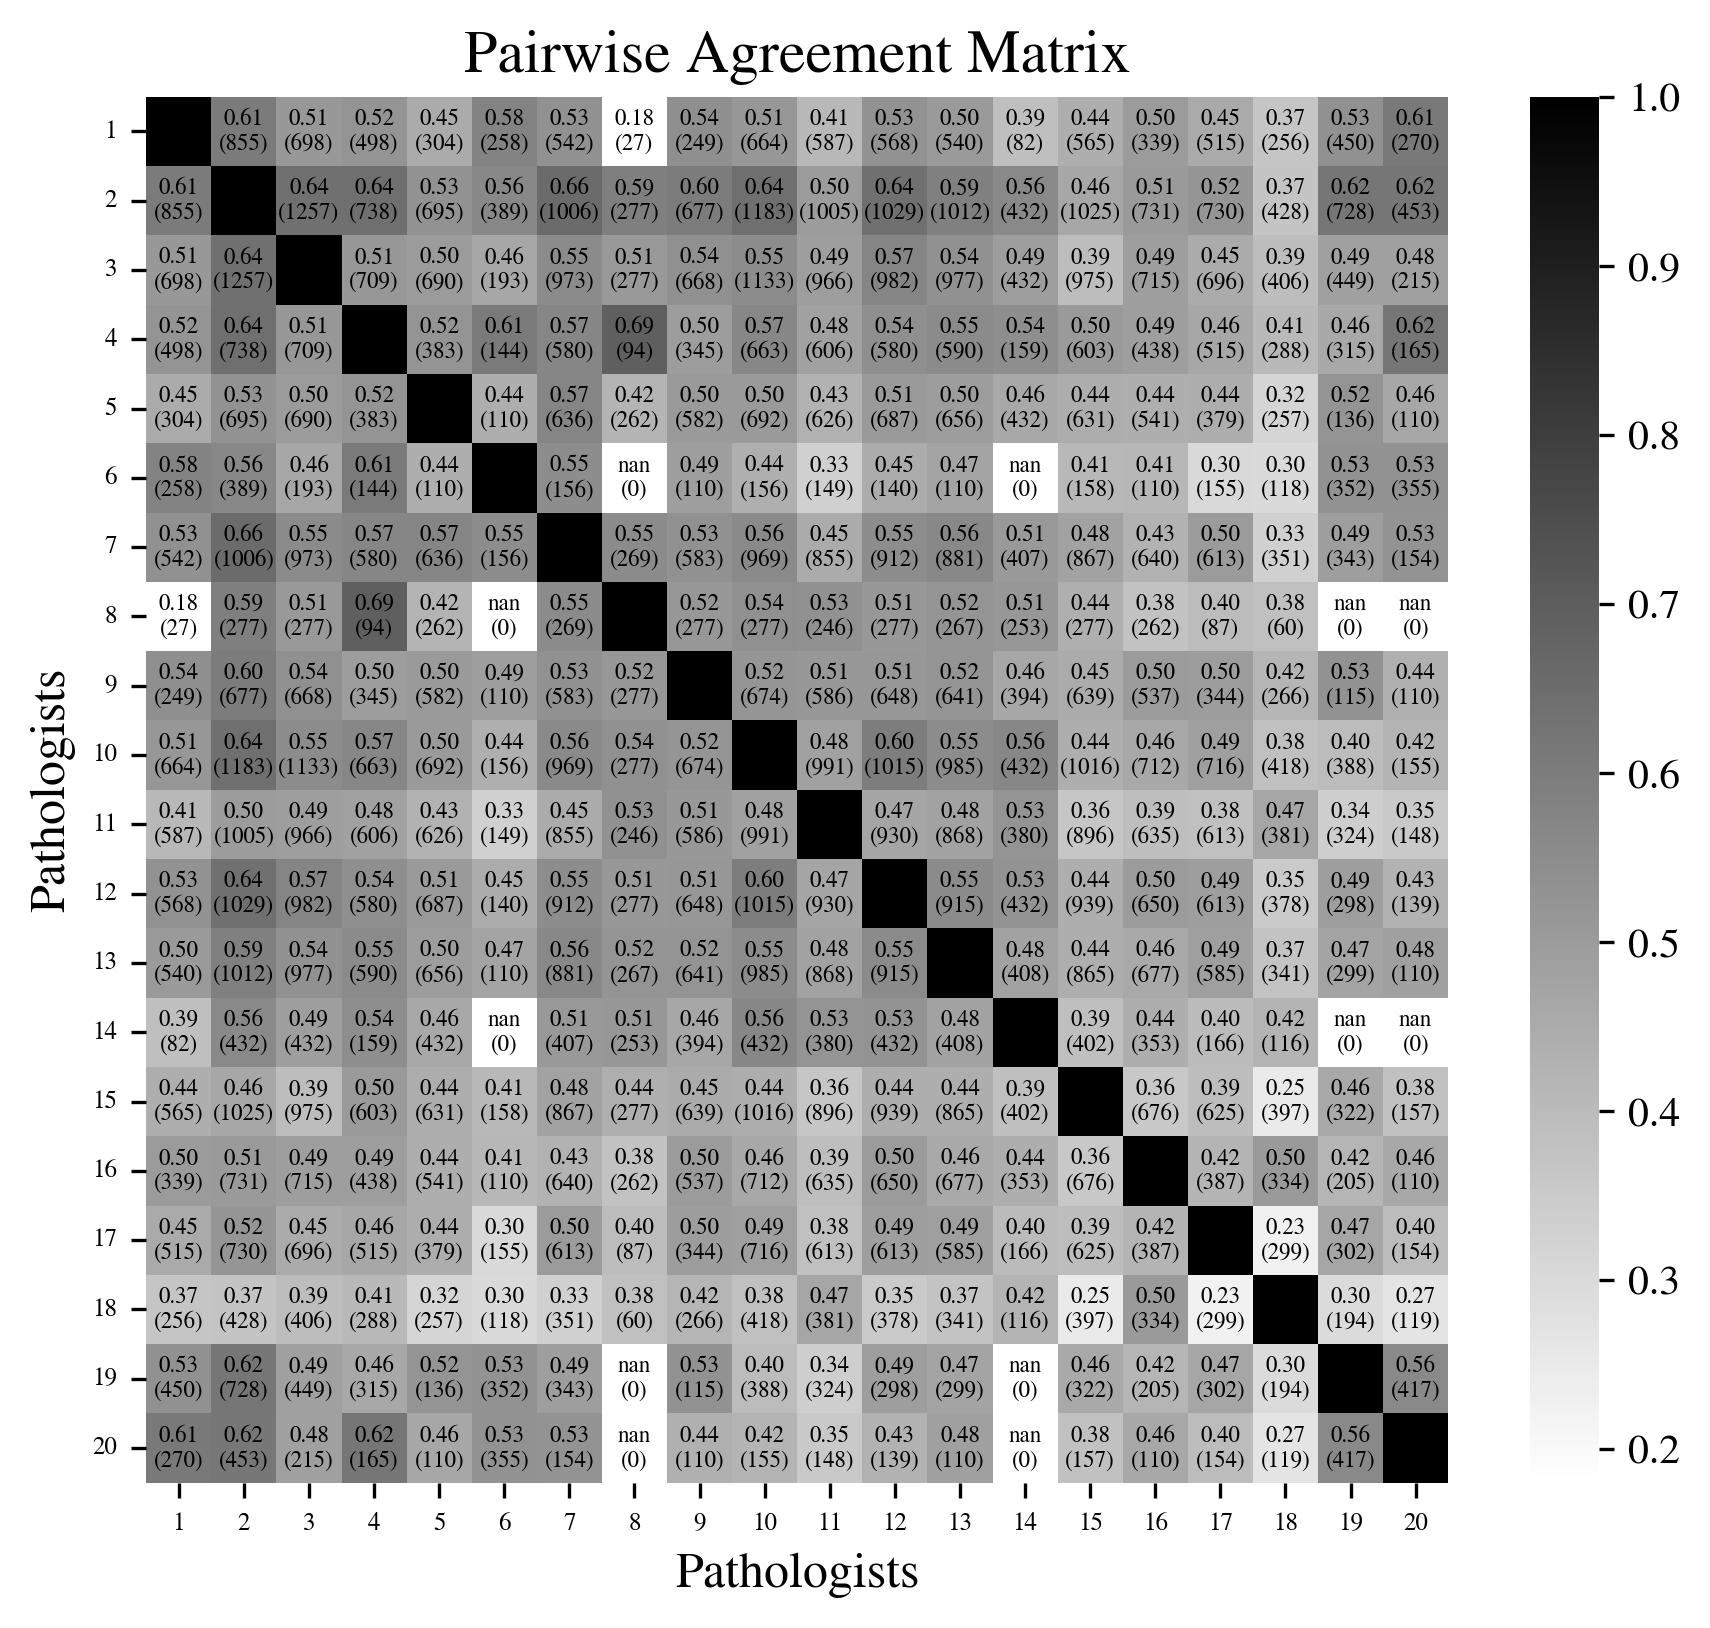

In [20]:
plt.figure(figsize=(7, 6))
sns.heatmap(pairwise_corr_nonagg.astype(float), annot=False, cmap=seq_cm, cbar=True)

annotate_heatmap(pairwise_corr_nonagg.values, number_of_common_rows_nonagg.values)
plt.xlabel("Pathologists")
plt.ylabel("Pathologists")
plt.yticks(rotation=0, fontsize=6)
plt.xticks(fontsize=6)
plt.title('Pairwise Agreement Matrix')
plt.show()

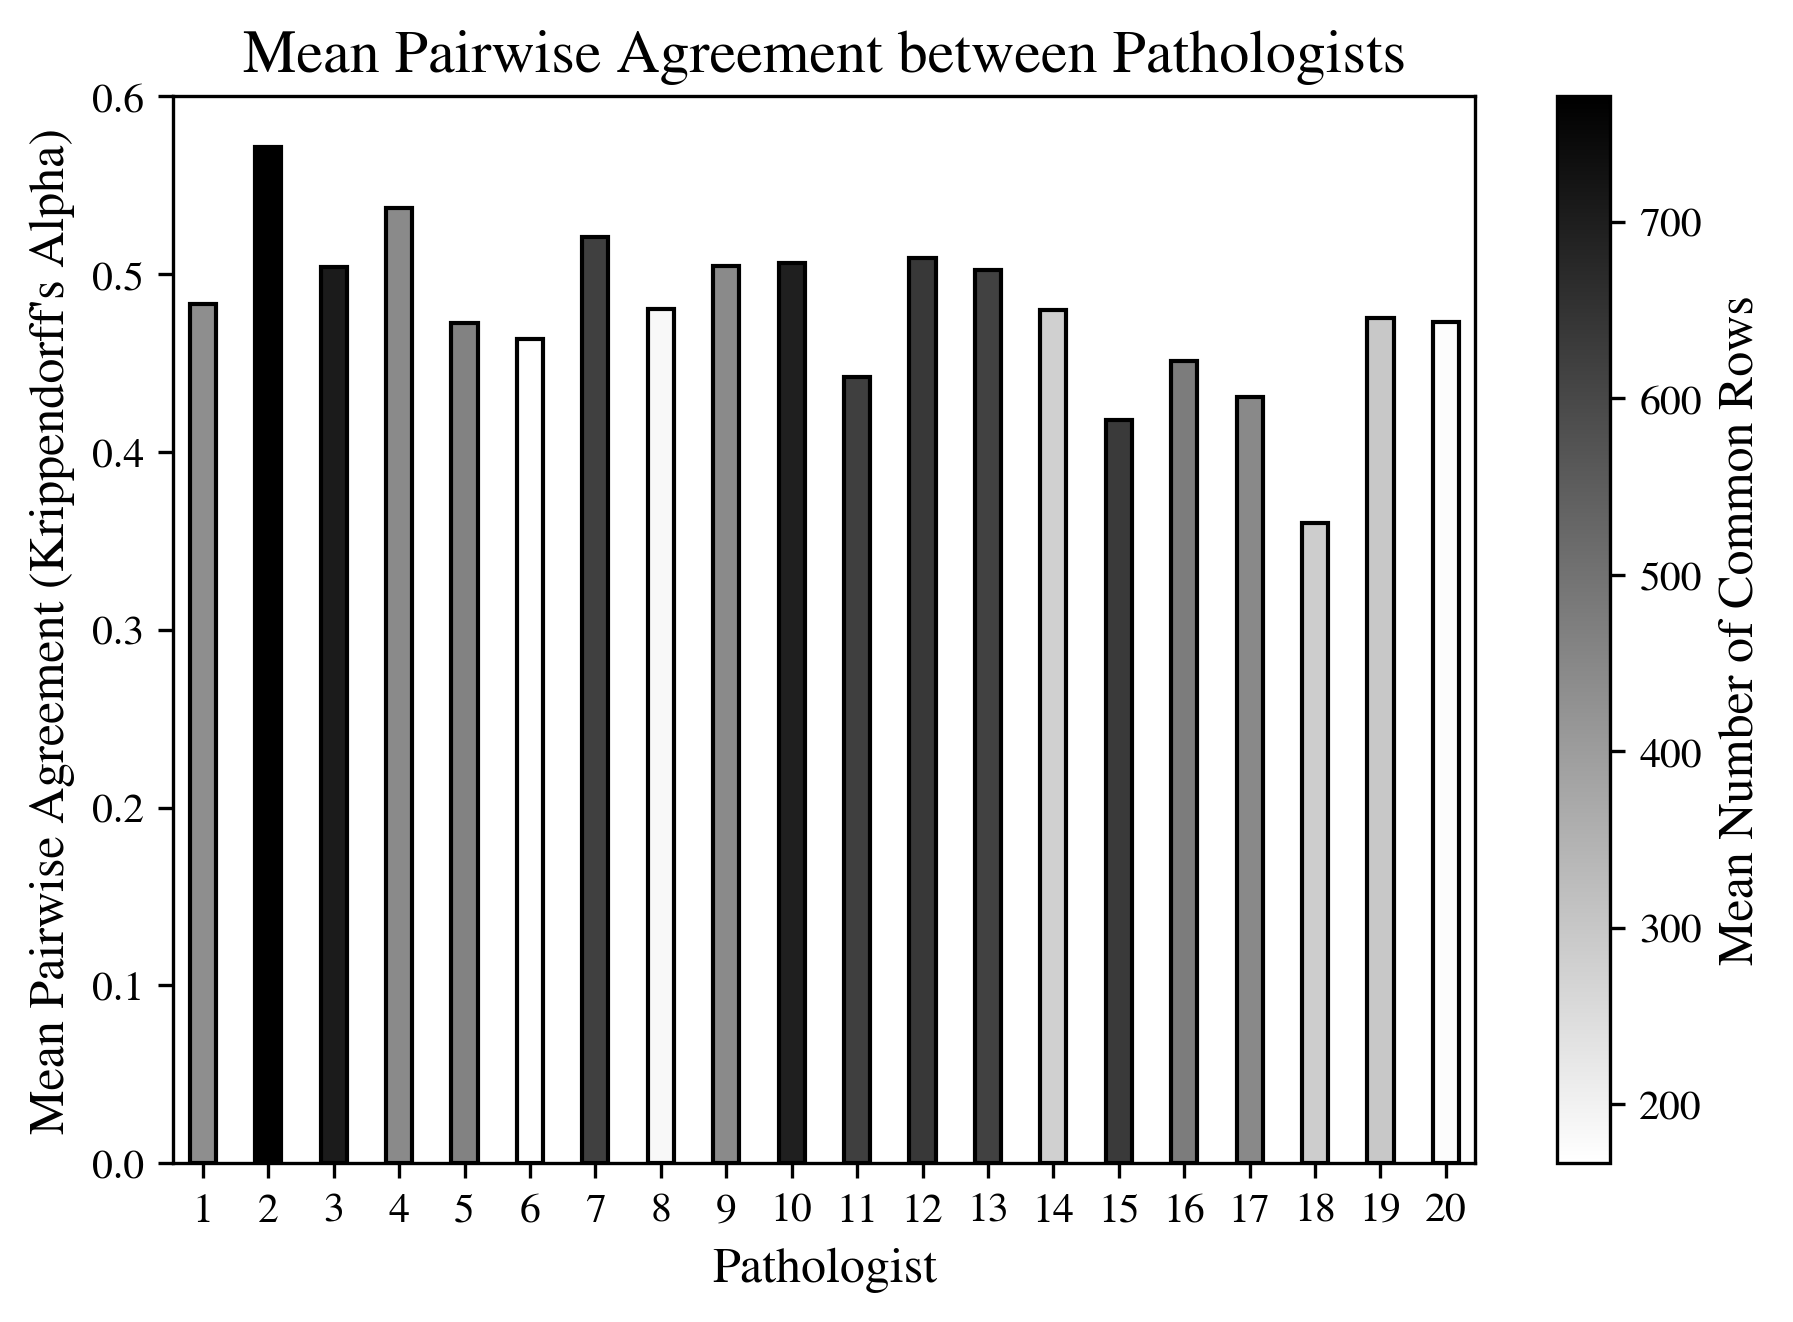

In [ ]:
mean_pairwise_corr_nonagg = pairwise_corr_nonagg.apply(lambda row: row.drop(row.name).mean(), axis=1)
mean_number_of_common_rows_nonagg = number_of_common_rows_nonagg.apply(lambda row: row.drop(row.name).mean(), axis=1)
normalized_common_rows_nonagg = (mean_number_of_common_rows_nonagg - mean_number_of_common_rows_nonagg.min()) / (mean_number_of_common_rows_nonagg.max() - mean_number_of_common_rows_nonagg.min())

colors = seq_cm(normalized_common_rows_nonagg)

fig, ax = plt.subplots(figsize=figsize_horizontal)
bars = mean_pairwise_corr_nonagg.plot(kind='bar', width=0.4, color=colors, edgecolor='black', ax=ax)

sm = cm.ScalarMappable(cmap=seq_cm, norm=plt.Normalize(vmin=mean_number_of_common_rows_nonagg.min(), vmax=mean_number_of_common_rows_nonagg.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Mean Number of Common Rows')

plt.title('Mean Pairwise Agreement between Pathologists')
plt.ylabel("Mean Pairwise Agreement (Krippendorff's Alpha)")
plt.xlabel("Pathologist")
plt.yticks()
plt.xticks(ticks=np.arange(len(pathologists)), labels=[f'{i+1}' for i in range(len(pathologists))], rotation=0)
plt.show()

In [25]:
temp = pd.DataFrame()
temp["abc"] = mean_pairwise_corr_nonagg
temp

,abc
1,0.483017
2,0.571429
3,0.504178
4,0.537319
5,0.472286
6,0.463540
7,0.521057
8,0.480322
9,0.504758
10,0.506253


In [ ]:
from sklearn.cluster import AgglomerativeClustering

distance = 1 - pairwise_corr_nonagg
distance.fillna(1, inplace=True)

clustering = AgglomerativeClustering(
    affinity='precomputed',
    linkage='average',
    n_clusters=5  
)
labels = clustering.fit_predict(distance)
results['agglo_labels'] = labels

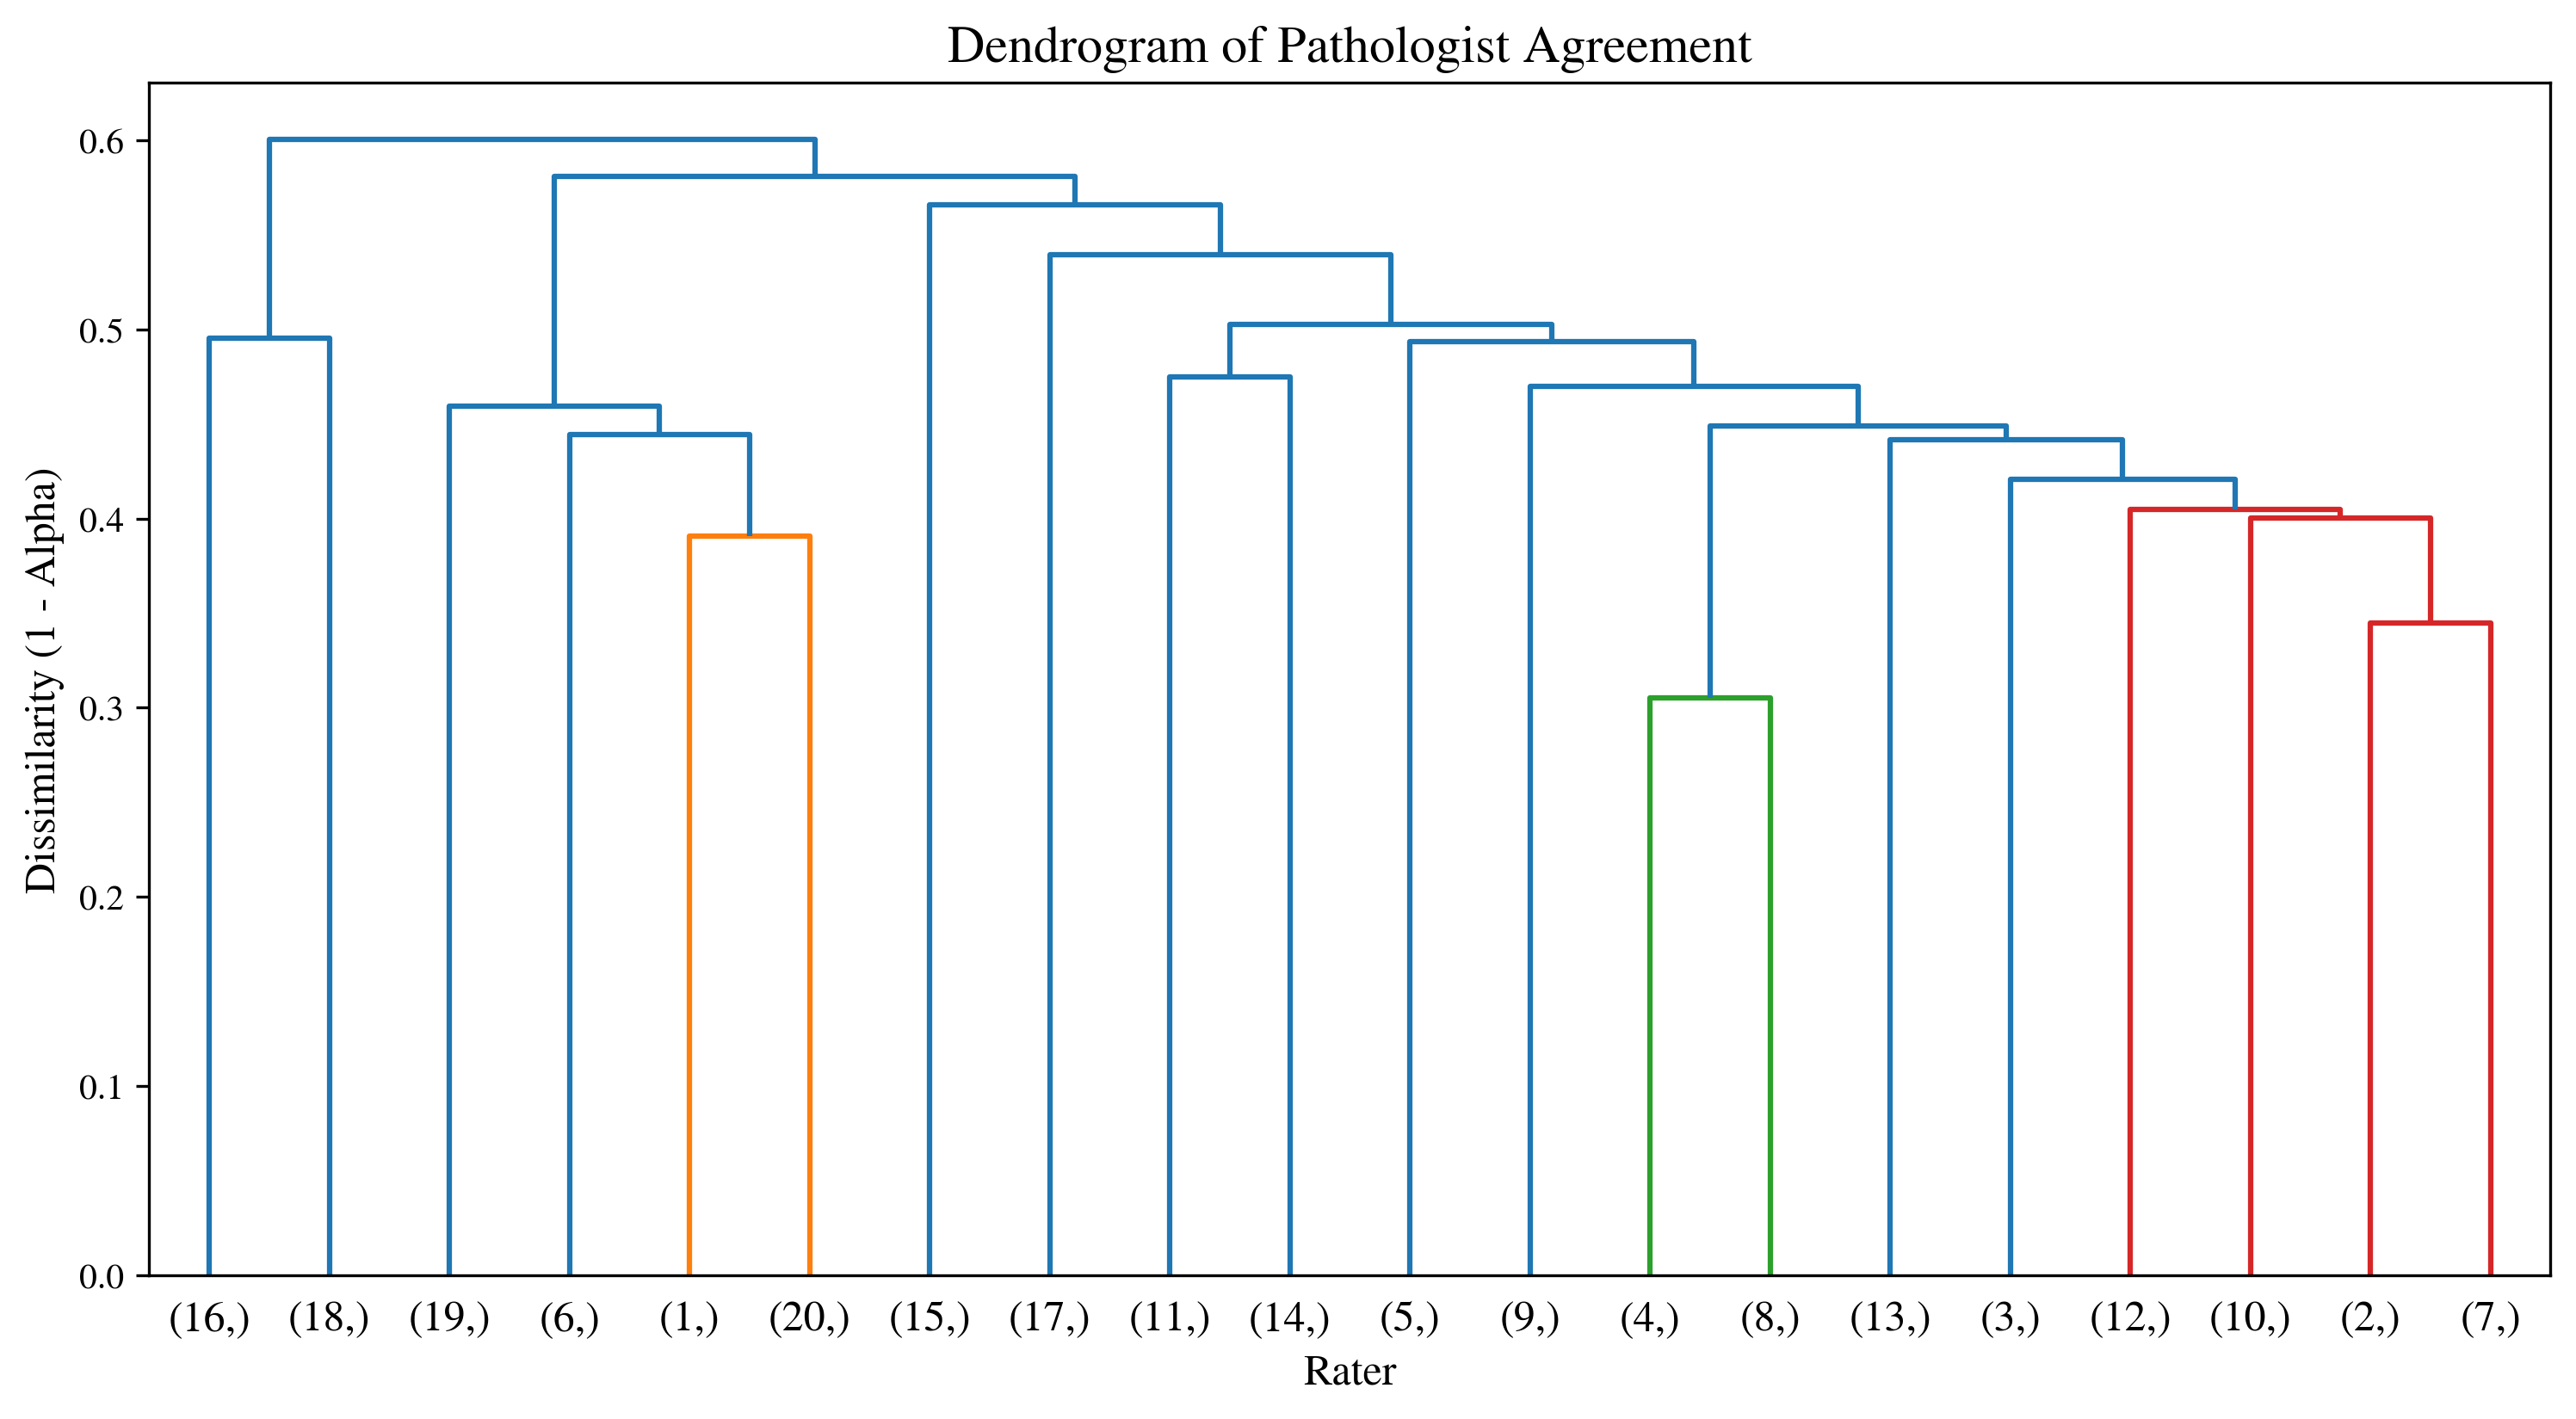

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform

condensed = squareform(distance.values)
Z = linkage(condensed, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z, labels=distance.index.tolist())
plt.title("Dendrogram of Pathologist Agreement")
plt.xlabel("Rater")
plt.ylabel("Dissimilarity (1 - Alpha)")
plt.show()


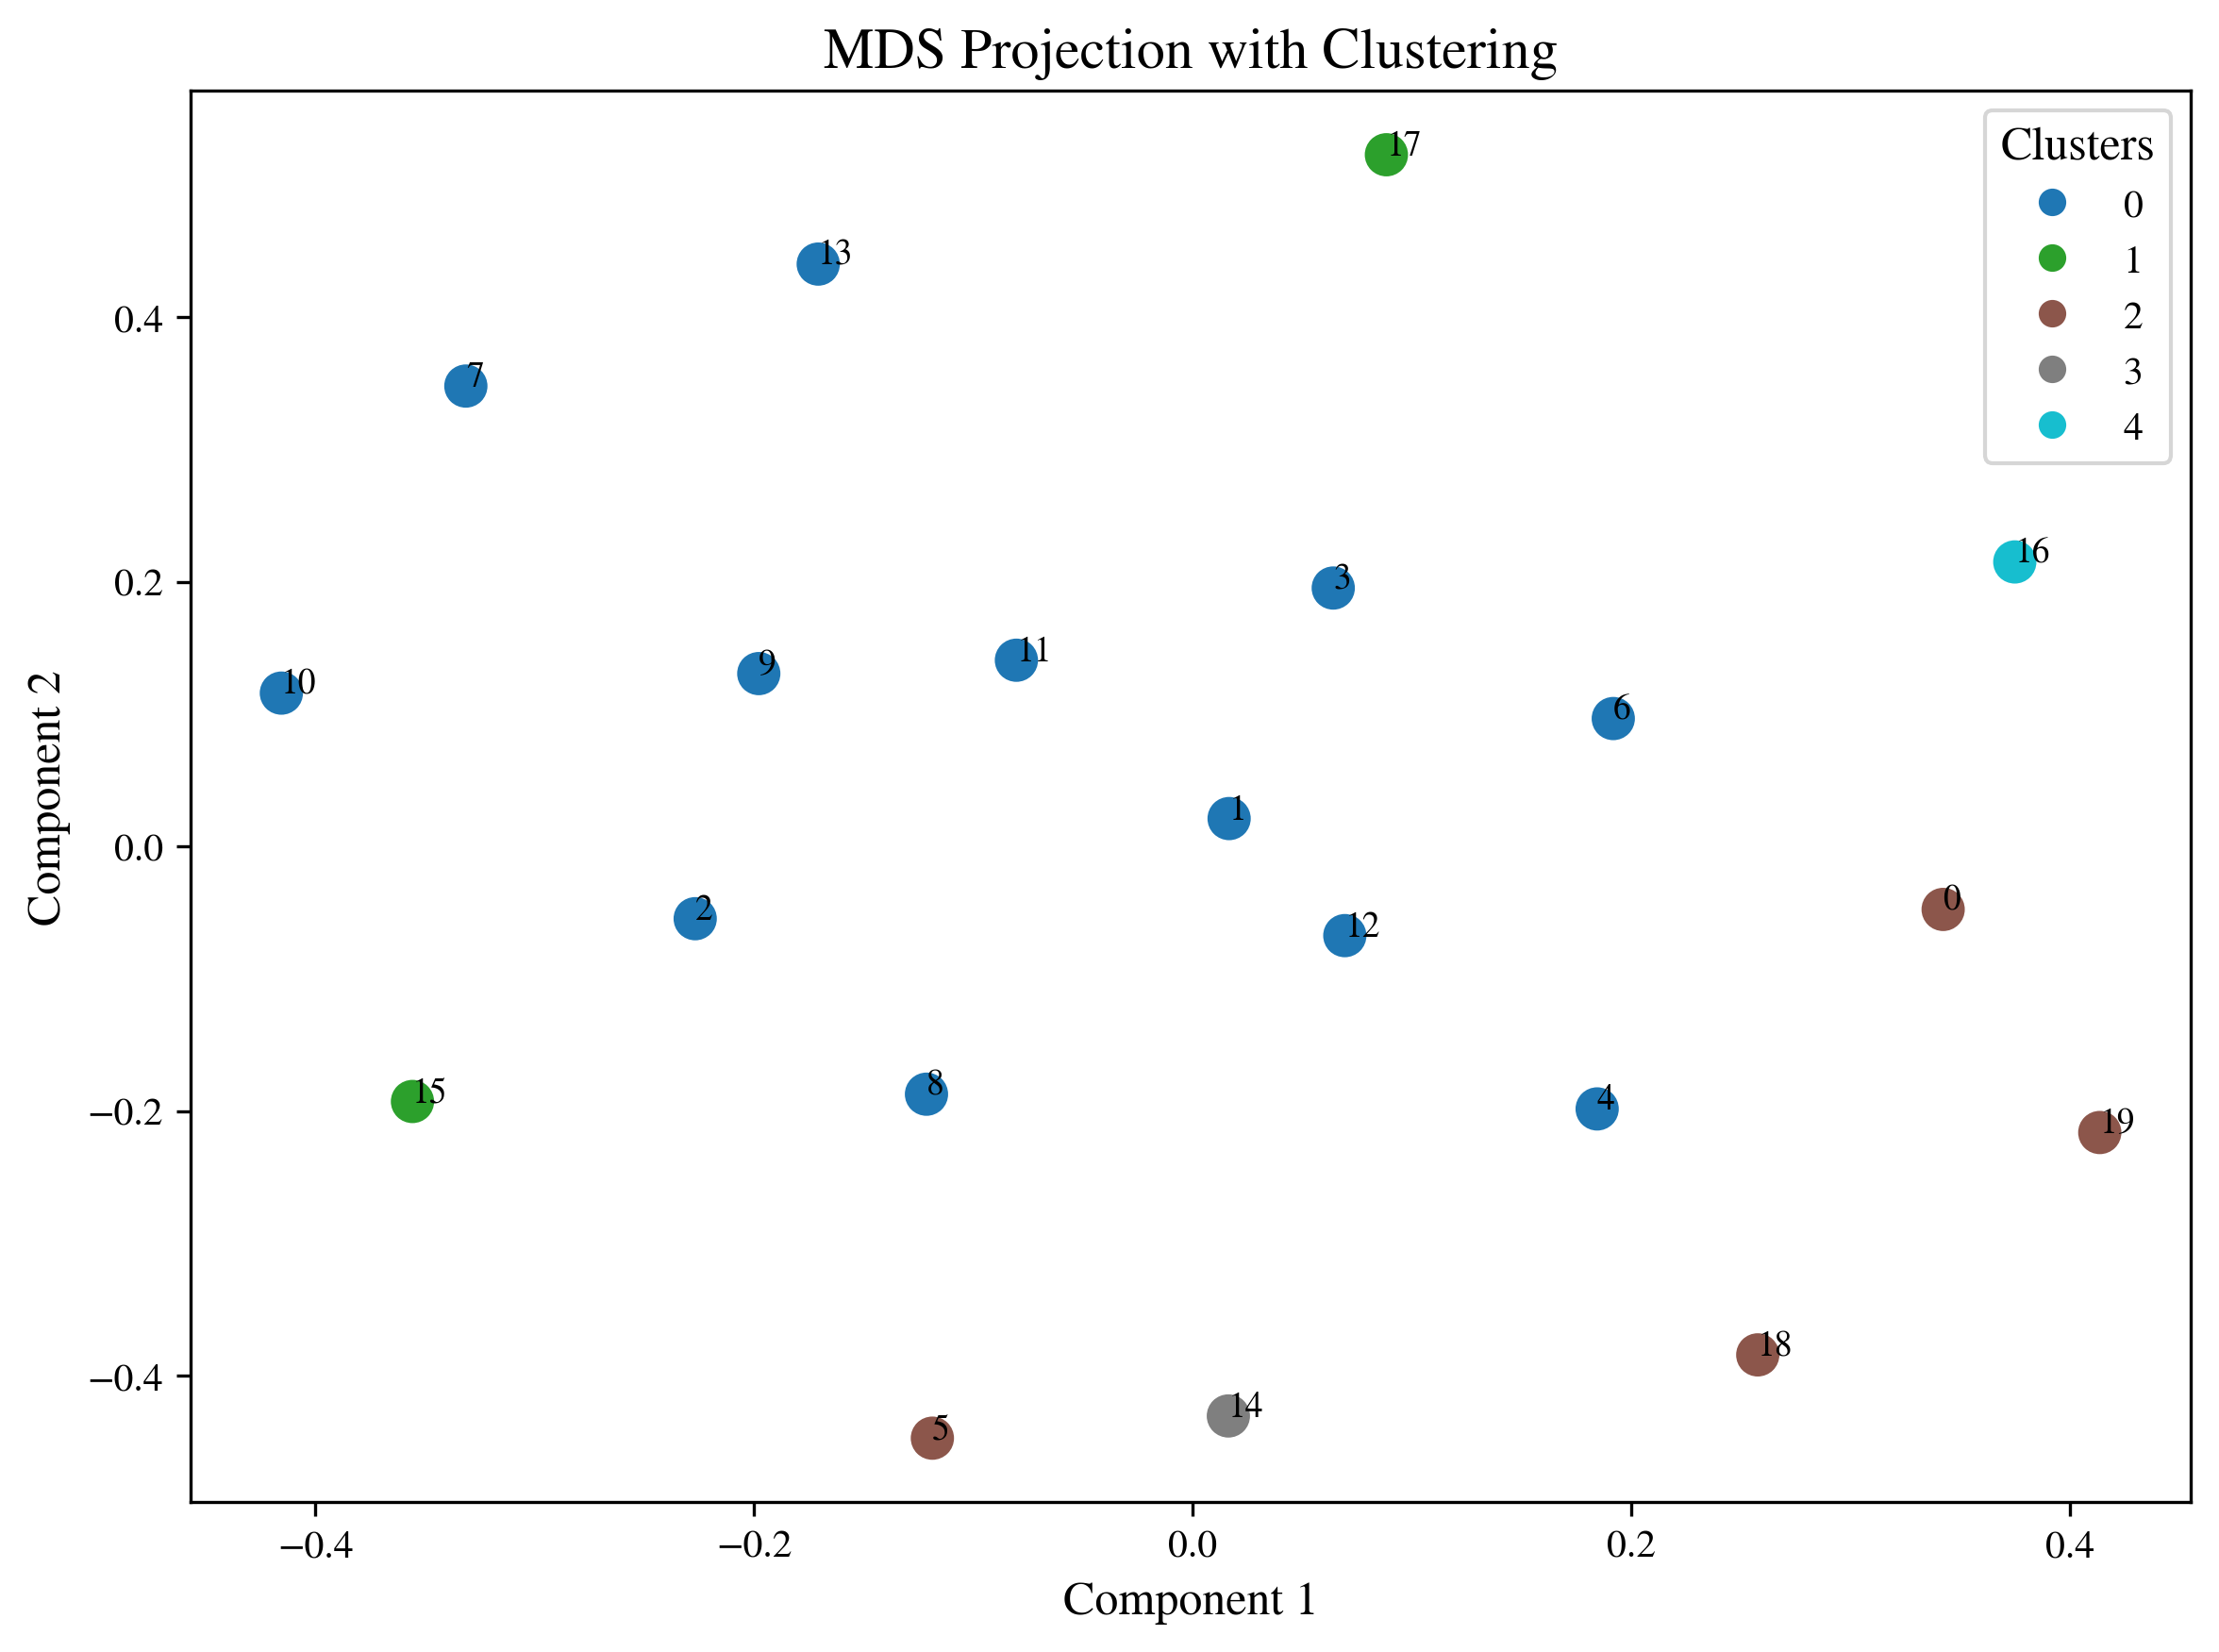

In [ ]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(distance)

# Clustering
clustering = AgglomerativeClustering(n_clusters=5, affinity='precomputed', linkage='average')
labels = clustering.fit_predict(distance)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10', s=100)
plt.title('MDS Projection with Clustering')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

# Adding text indicating pathologist id
for i in range(len(coords)):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=9)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.tight_layout()
plt.show()

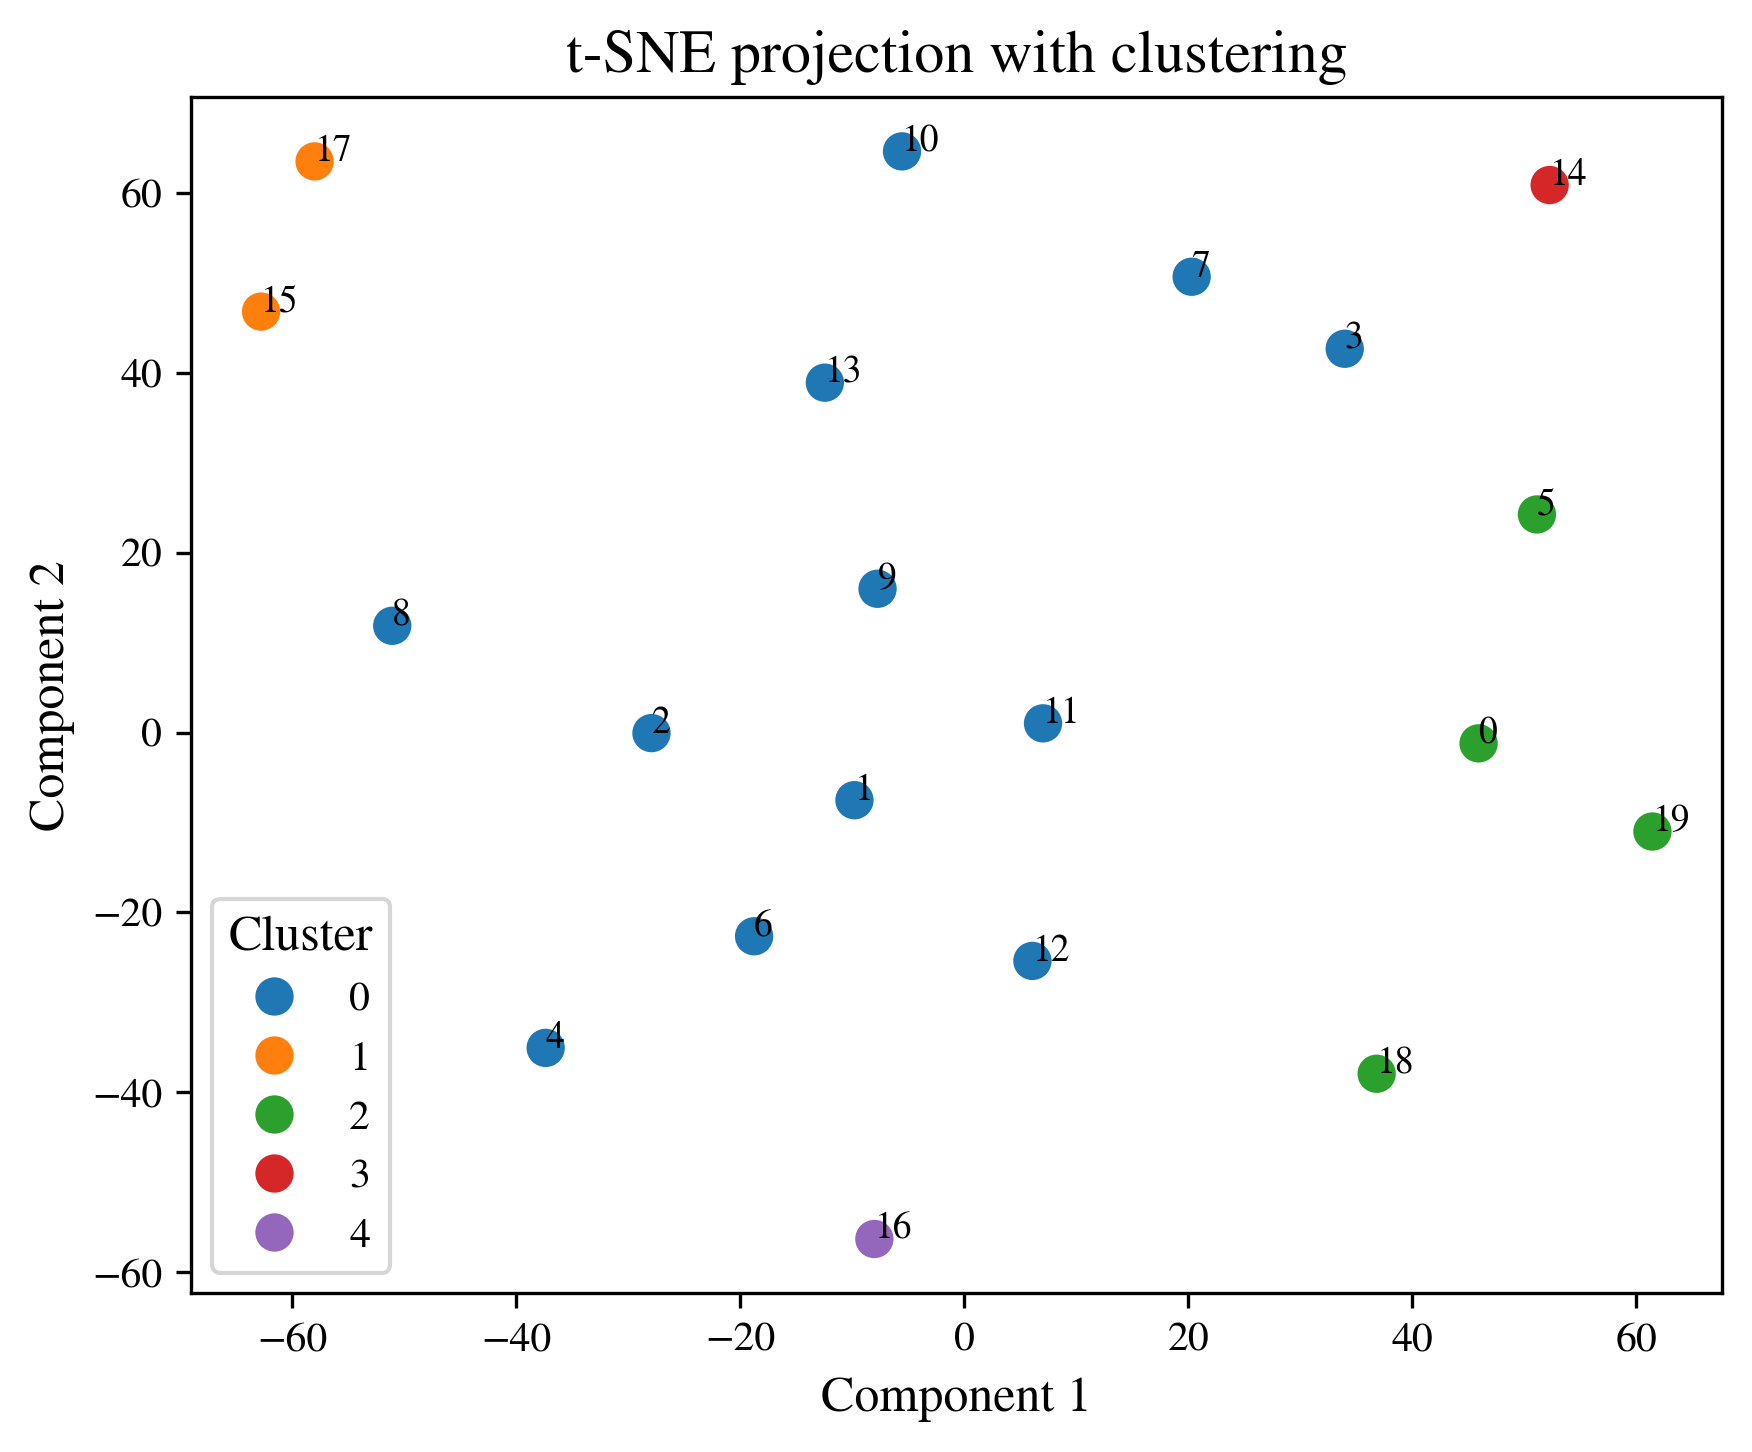

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns

tsne = TSNE(n_components=2, metric='precomputed', perplexity=5, init='random', random_state=42)
tsne_coords = tsne.fit_transform(distance)

clustering = AgglomerativeClustering(n_clusters=5, affinity='precomputed', linkage='average')
labels = clustering.fit_predict(distance)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=labels, palette='tab10', s=100)
plt.title("t-SNE projection with clustering")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title="Cluster", loc="best")

for i in range(len(tsne_coords)):
    plt.text(tsne_coords[i, 0], tsne_coords[i, 1], str(i), fontsize=9)

plt.tight_layout()
plt.show()


## selection

In [ ]:
highest_alpha = results.loc[results.groupby('agglo_labels')['alpha'].idxmax()]
highest_alpha


,path_id,alpha,agglo_labels
1,2,0.824960,0
15,16,0.586628,1
19,20,0.716195,2
14,15,0.688525,3
16,17,0.603757,4


In [ ]:
results.sort_values(by='alpha', ascending=False, inplace=True)
results.head()

,path_id,alpha,agglo_labels
1,2,0.824960,0
12,13,0.821839,0
9,10,0.774385,0
3,4,0.738225,0
11,12,0.723177,0
